# 03 - Correlation Matrices Analysis and Eigendecomposition

In this notebook we perform a comprehensive analysis of correlation matrices stored in `correlation_matrices/<FILE_NAME>_w<WINDOW_LENGTH>_s<STRIDE>.pt`, including:
- **Correlation value distribution analysis**: Examining the statistical properties of all pairwise correlations across all time windows
- **Eigendecomposition**: Computing eigenvalues and eigenvectors for each correlation matrix

## Correlation Values Analysis

We extract and analyze all unique correlation values from the upper triangular part of each correlation matrix. This provides insights into:
- The overall correlation structure of the asset market
- Distribution of positive vs. negative correlations
- Temporal evolution of correlation patterns

## Eigendecomposition of Correlation Matrices

The eigendecomposition of correlation matrices provides insights into the principal components (principal correlations) of the asset market and their evolution over time.

For a symmetric correlation matrix $C \in \mathbb{R}^{n \times n}$, we compute:
- $\lambda_i$: eigenvalues (sorted in descending order)
- $v_i$: corresponding eigenvectors

The explained variance ratio for the $k$-th eigenvalue is:
$$
\text{EV}_k = \frac{\lambda_k}{\sum_{i=1}^{n} \lambda_i}
$$

This helps us understand which principal correlations dominate the market structure and how many principal components are needed to explain the variance in the correlation matrix.

In [50]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

torch.set_printoptions(linewidth=200, precision=4, sci_mode=False)

# Global matrix selection for all analyses in this notebook
# Options:
#   - 'all': use all windows
#   - integer (0 to num_windows-1): use one window
#   - 'start:stop' (e.g., '49:460'): use an inclusive window range [start, stop] (Zero-based indexing)
SELECTED_CORR_MATRIX = 150
FILE_NAME = 'data_00_20'
WINDOW_LENGTH = 724
STRIDE = 10

In [51]:
def parse_selected_corr_matrix(selected_corr_matrix, num_matrices):
    """Return selected indices, display label, and selection type (all/range/single).

    NOTE: indexing is always zero-based.
    For range selection, 'start:stop' is inclusive on both ends.
    """
    if selected_corr_matrix == 'all':
        return np.arange(num_matrices), 'All Windows', 'all'

    if isinstance(selected_corr_matrix, str) and ':' in selected_corr_matrix:
        start_str, stop_str = selected_corr_matrix.split(':')
        start_idx, stop_idx = int(start_str), int(stop_str)
        if not (0 <= start_idx <= stop_idx < num_matrices):
            raise ValueError(
                f"Invalid SELECTED_CORR_MATRIX range: {selected_corr_matrix}. "
                f"Expected zero-based inclusive 'start:stop' with 0 <= start <= stop < {num_matrices}."
            )
        return np.arange(start_idx, stop_idx + 1), f'Windows {start_idx}:{stop_idx}', 'range'

    matrix_idx = int(selected_corr_matrix)
    if not (0 <= matrix_idx < num_matrices):
        raise ValueError(
            f"Invalid SELECTED_CORR_MATRIX index: {matrix_idx}. "
            f"Valid zero-based range is [0, {num_matrices - 1}]."
        )

    return np.array([matrix_idx]), f'Matrix index {matrix_idx}', 'single'


def extract_and_sanitize_correlation_matrix(corr_tensor_input, matrix_idx):
    if hasattr(corr_tensor_input, 'cpu'):
        # It's a torch tensor
        corr_matrix = corr_tensor_input[matrix_idx].cpu().numpy()
    else:
        # It's already numpy
        corr_matrix = np.array(corr_tensor_input[matrix_idx], dtype=float)
    
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    corr_matrix = (corr_matrix + corr_matrix.T) / 2.0
    np.fill_diagonal(corr_matrix, 1.0)
    
    return corr_matrix


def build_distance_matrix(corr_matrix):
    dist_matrix = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - corr_matrix)))
    dist_matrix = (dist_matrix + dist_matrix.T) / 2.0
    np.fill_diagonal(dist_matrix, 0.0)
    
    return dist_matrix

In [52]:
# ===== SET UP RESULTS FOLDER =====
RESULTS_BASE = Path('../results')
RESULTS_MAIN_FOLDER = RESULTS_BASE / f'{FILE_NAME}_w{WINDOW_LENGTH}_s{STRIDE}'
RESULTS_MAIN_FOLDER.mkdir(parents=True, exist_ok=True)

if SELECTED_CORR_MATRIX == 'all':
    subfolder_name = 'all'
elif isinstance(SELECTED_CORR_MATRIX, str) and ':' in SELECTED_CORR_MATRIX:
    start, stop = SELECTED_CORR_MATRIX.split(':')
    subfolder_name = f'windows_{start}_{stop}'
else:
    subfolder_name = f'matrix_{SELECTED_CORR_MATRIX}'

RESULTS_FOLDER = RESULTS_MAIN_FOLDER / subfolder_name
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Selected analysis: {SELECTED_CORR_MATRIX}")
print(f"Results will be saved to: {RESULTS_FOLDER.resolve()}")

Selected analysis: 150
Results will be saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\matrix_150


## Section 1: Load Correlation Matrices Dataset

Load the correlation matrices dataset from the saved PyTorch file and extract all components needed for eigendecomposition analysis.

In [53]:
TENSOR_PATH = Path(f'../data/processed/correlation_matrices/{FILE_NAME}_w{WINDOW_LENGTH}_s{STRIDE}.pt')
checkpoint = torch.load(TENSOR_PATH)

corr_tensor = checkpoint['corr_tensor']
window_ranges = checkpoint['window_ranges']
window_length = checkpoint['window_length']
stride = checkpoint['stride']
tickers = checkpoint['tickers']
timestamps = checkpoint['timestamps']

num_windows = corr_tensor.shape[0]
num_assets = corr_tensor.shape[1]

print(f'Tensor loaded from: {TENSOR_PATH.resolve()}')
print('\n--- Loaded Data Structure ---')
print(f"corr_tensor shape: {corr_tensor.shape}")
print(f"  - Dimension 0 (num_windows): {corr_tensor.shape[0]} rolling windows")
print(f"  - Dimension 1 (num_assets): {corr_tensor.shape[1]} assets")
print(f"  - Dimension 2 (num_assets): {corr_tensor.shape[2]} assets (symmetric matrix)")
print(f"window_length: {window_length} days per window")
print(f"stride: {stride} days between consecutive windows")
print(f"num_tickers: {len(tickers)} tickers")
print(f"tickers (first 5): {tickers[:5]}")
print(f"window_ranges (first 3): {window_ranges[:3]}")
print(f"timestamps (first 5): {timestamps[:5]}")

Tensor loaded from: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\data\processed\correlation_matrices\data_00_20_w724_s10.pt

--- Loaded Data Structure ---
corr_tensor shape: torch.Size([461, 362, 362])
  - Dimension 0 (num_windows): 461 rolling windows
  - Dimension 1 (num_assets): 362 assets
  - Dimension 2 (num_assets): 362 assets (symmetric matrix)
window_length: 724 days per window
stride: 10 days between consecutive windows
num_tickers: 362 tickers
tickers (first 5): ['AAPL', 'ABC', 'ABMD', 'ABT', 'ADBE']
window_ranges (first 3): [(0, 724), (10, 734), (20, 744)]
timestamps (first 5): ['1999-11-02', '1999-11-03', '1999-11-04', '1999-11-05', '1999-11-08']


## Section 2: Correlation Matrices Analysis
### Property 1: The distribution of pairwise correlations is significantly shifted towards positive values

Extract all correlation values from the matrices and analyze their distribution using histograms and statistics.

--- Correlation Values Statistics (Matrix index 150) ---

Total number of correlation values: 65341
Mean correlation: 0.3021
Std deviation: 0.1192
Min correlation: -0.2307
Max correlation: 0.8651
Median correlation: 0.2944

Correlation sign distribution:
  Positive (> 0): 65242 (99.85%)
  Negative (< 0): 99 (0.15%)
  Zero (= 0): 0 (0.00%)

✓ Plot saved to: ..\results\data_00_20_w724_s10\matrix_150\1_correlation_values_distribution.png


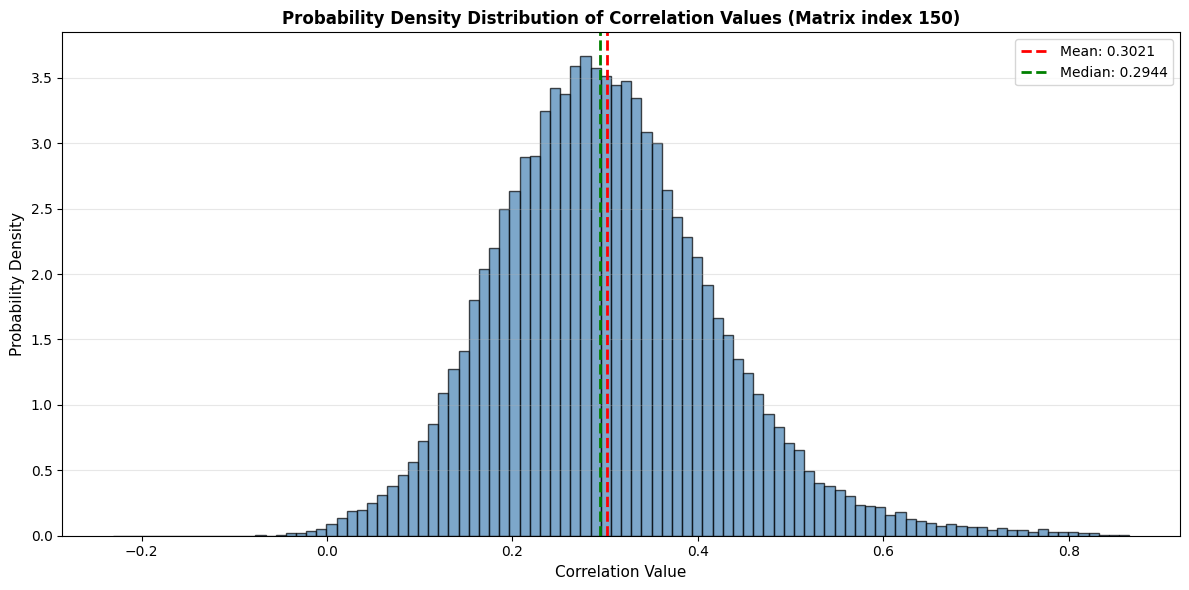


✓ Correlation value probability density visualization complete!


In [54]:
# Extract correlation values from the tensor
# Extract upper triangular indices (excluding diagonal)
triu_indices = torch.triu_indices(num_assets, num_assets, offset=1)
all_corr_values = []

selected_indices, corr_title, _ = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_windows)

for i in selected_indices:
    corr_matrix = corr_tensor[i]
    # Get all unique correlation values (upper triangular part)
    corr_values = corr_matrix[triu_indices[0], triu_indices[1]]
    all_corr_values.append(corr_values)

# Concatenate all correlation values
all_corr_values_flat = torch.cat(all_corr_values)

print(f"--- Correlation Values Statistics ({corr_title}) ---\n")
print(f"Total number of correlation values: {len(all_corr_values_flat)}")
print(f"Mean correlation: {torch.mean(all_corr_values_flat):.4f}")
print(f"Std deviation: {torch.std(all_corr_values_flat):.4f}")
print(f"Min correlation: {torch.min(all_corr_values_flat):.4f}")
print(f"Max correlation: {torch.max(all_corr_values_flat):.4f}")
print(f"Median correlation: {torch.median(all_corr_values_flat):.4f}")

# Count positive and negative correlations
positive_corrs = torch.sum(all_corr_values_flat > 0).item()
negative_corrs = torch.sum(all_corr_values_flat < 0).item()
zero_corrs = torch.sum(all_corr_values_flat == 0).item()

print(f"\nCorrelation sign distribution:")
print(f"  Positive (> 0): {positive_corrs} ({100*positive_corrs/len(all_corr_values_flat):.2f}%)")
print(f"  Negative (< 0): {negative_corrs} ({100*negative_corrs/len(all_corr_values_flat):.2f}%)")
print(f"  Zero (= 0): {zero_corrs} ({100*zero_corrs/len(all_corr_values_flat):.2f}%)")

# Visualization of correlation values as probability density
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram of all correlation values with normalized density
ax.hist(all_corr_values_flat.numpy(), bins=100, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax.axvline(torch.mean(all_corr_values_flat).item(), color='red', linestyle='--', linewidth=2, label=f'Mean: {torch.mean(all_corr_values_flat):.4f}')
ax.axvline(torch.median(all_corr_values_flat).item(), color='green', linestyle='--', linewidth=2, label=f'Median: {torch.median(all_corr_values_flat):.4f}')
ax.set_xlabel('Correlation Value', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title(f'Probability Density Distribution of Correlation Values ({corr_title})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save the figure
plot_path = RESULTS_FOLDER / '1_correlation_values_distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Plot saved to: {plot_path}")

plt.show()

print("\n✓ Correlation value probability density visualization complete!")

### Property 2: Eigenvalues follow the Marchenko–Pastur distribution, except for a very large first eigenvalue and a couple of other large eigenvalues

For each correlation matrix, compute eigenvalues and eigenvectors using `torch.linalg.eigh()`. This function returns eigenvalues in ascending order.

In [55]:
# Compute eigenvalues and eigenvectors for each correlation matrix
num_windows = corr_tensor.shape[0]
num_assets = corr_tensor.shape[1]

eigenvalues_list = []
eigenvectors_list = []

print(f"Computing eigendecomposition for {num_windows} correlation matrices...")

for i in range(num_windows):
    # Get the i-th correlation matrix
    corr_matrix = corr_tensor[i]
    
    # Compute eigenvalues and eigenvectors
    # torch.linalg.eigh returns eigenvalues in ascending order
    evals, evecs = torch.linalg.eigh(corr_matrix)
    
    # Reverse to get descending order (highest eigenvalues first)
    evals = torch.flip(evals, dims=[0])
    evecs = torch.flip(evecs, dims=[1])
    
    eigenvalues_list.append(evals)
    eigenvectors_list.append(evecs)
    
    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{num_windows} windows")

# Convert lists to tensors
eigenvalues_tensor = torch.stack(eigenvalues_list, dim=0)  # Shape: (num_windows, num_assets)
eigenvectors_tensor = torch.stack(eigenvectors_list, dim=0)  # Shape: (num_windows, num_assets, num_assets)

print(f"\n✓ Eigendecomposition complete!")
print(f"eigenvalues_tensor shape: {eigenvalues_tensor.shape}")
print(f"eigenvectors_tensor shape: {eigenvectors_tensor.shape}")
print(f"\nFirst window eigenvalues (top 10): {eigenvalues_tensor[0, :10]}")

Computing eigendecomposition for 461 correlation matrices...
  Processed 100/461 windows
  Processed 200/461 windows
  Processed 300/461 windows
  Processed 400/461 windows

✓ Eigendecomposition complete!
eigenvalues_tensor shape: torch.Size([461, 362])
eigenvectors_tensor shape: torch.Size([461, 362, 362])

First window eigenvalues (top 10): tensor([67.0290, 20.5788, 10.1428,  7.8826,  6.5442,  6.1857,  5.9010,  4.3358,  3.8480,  3.5165])


In [56]:
eigenvalues_np = eigenvalues_tensor.cpu().numpy()
negative_eigenvalues_count = np.sum(eigenvalues_np < 0)
print(f"\nNumber of negative eigenvalues across all windows: {negative_eigenvalues_count}")


Number of negative eigenvalues across all windows: 0



Statistics for Matrix index 150:
Count: 362
Min: 0.025961
Max: 115.763275

Marchenko-Pastur bounds:
  a (lower bound): 0.085786
  b (upper bound): 2.914214

Eigenvalues ABOVE Marchenko-Pastur limit (b=2.914214):
   1. 115.763275
   2. 17.580864
   3. 10.095474
   4. 7.613637
   5. 5.091724
   6. 4.282140
   7. 3.645986
   8. 3.367626
   9. 3.132375

Eigenvalues BELOW or WITHIN Marchenko-Pastur bounds: 353

✓ Plot saved to: ..\results\data_00_20_w724_s10\matrix_150\2a_eigenvalue_distribution_marchenko_pastur.png


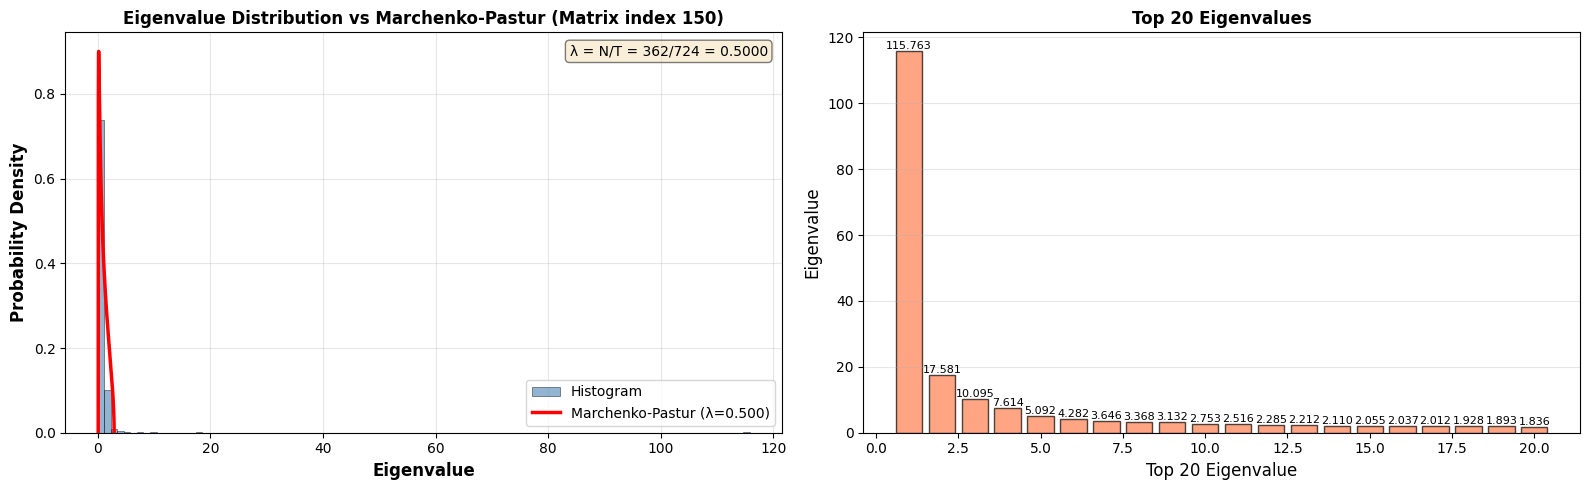

In [57]:
eigenvalues_np = eigenvalues_tensor.cpu().numpy()

# ===== MARCHENKO-PASTUR FUNCTION =====
def marchenko_pastur_pdf(x, lmbd, sigma=1):
    """
    Marchenko-Pastur probability density function.

    Parameters:
    -----------
    x : float or array
        Eigenvalue
    lmbd : float
        Ratio of num_eigenvalues / num_time_points (N/T)
    sigma : float
        Standard deviation (typically 1 for correlation matrices)

    Returns:
    --------
    float or array
        Probability density at x
    """
    b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
    a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

    # Vectorized calculation
    result = np.zeros_like(x, dtype=float)
    mask = (x >= a) & (x <= b)
    result[mask] = (1 / (2 * np.pi * sigma * sigma * x[mask] * lmbd)) * np.sqrt((b - x[mask]) * (x[mask] - a))

    return result

# Select data based on global choice
selected_indices, selection_label, selection_type = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_windows)
if selection_type == 'single':
    data = eigenvalues_np[selected_indices[0]]
else:
    data = eigenvalues_np[selected_indices].flatten()

# Clip negative values to 0 (numerical errors in correlation matrices)
# Eigenvalues of correlation matrices should be non-negative
data = np.clip(data, 0, None)

# Calculate Marchenko-Pastur parameters
# lambda = number of assets / window length
lmbd = num_assets / window_length
sigma = 1.0

# Create histogram with density=True for probability density
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: Histogram with Marchenko-Pastur overlay
ax = axes[0]
n, bins, patches = ax.hist(data, bins=100, density=True, alpha=0.6,
                            color='steelblue', edgecolor='black', linewidth=0.5,
                            label='Histogram')

# Calculate Marchenko-Pastur bounds
b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

# Create x range for theoretical curve (excluding top eigenvalues)
x_min = a
x_max = b

x_theory = np.linspace(x_min, x_max, 500)
y_theory = marchenko_pastur_pdf(x_theory, lmbd, sigma)

# Plot the theoretical Marchenko-Pastur density
ax.plot(x_theory, y_theory, 'r-', linewidth=2.5, label=f'Marchenko-Pastur (λ={lmbd:.3f})')

ax.set_xlabel('Eigenvalue', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax.set_title(f'Eigenvalue Distribution vs Marchenko-Pastur ({selection_label})', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add text annotation with lambda value
textstr = f'λ = N/T = {num_assets}/{window_length} = {lmbd:.4f}'
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right plot: Top eigenvalues as bar chart
ax = axes[1]
if selection_type == 'single':
    eigenvalues = eigenvalues_np[selected_indices[0]]
else:
    # For all/range selections, show sorted mean eigenvalues
    eigenvalues = eigenvalues_np[selected_indices].mean(axis=0)

# Sort in descending order and take top values
top_k = min(20, len(eigenvalues))
top_eigenvalues = np.sort(eigenvalues)[::-1][:top_k]
ranks = np.arange(1, top_k + 1)

ax.bar(ranks, top_eigenvalues, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Top 20 Eigenvalue', fontsize=12)
ax.set_ylabel('Eigenvalue', fontsize=12)
ax.set_title(f'Top {top_k} Eigenvalues', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (rank, val) in enumerate(zip(ranks, top_eigenvalues)):
    ax.text(rank, val, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Print statistics
print(f"\n{'='*50}")
print(f"Statistics for {selection_label}:")
print(f"{'='*50}")
print(f"Count: {len(data)}")
print(f"Min: {np.min(data):.6f}")
print(f"Max: {np.max(data):.6f}")
print(f"\nMarchenko-Pastur bounds:")
print(f"  a (lower bound): {a:.6f}")
print(f"  b (upper bound): {b:.6f}")

# Identify eigenvalues above the Marchenko-Pastur limit (anomalies)
if selection_type == 'single':
    eigenvalues_full = eigenvalues_np[selected_indices[0]]
else:
    eigenvalues_full = eigenvalues_np[selected_indices].mean(axis=0)

eigenvalues_above_b = eigenvalues_full[eigenvalues_full > b]

print(f"\nEigenvalues ABOVE Marchenko-Pastur limit (b={b:.6f}):")
if len(eigenvalues_above_b) > 0:
    for i, val in enumerate(sorted(eigenvalues_above_b, reverse=True), 1):
        print(f"  {i:2d}. {val:.6f}")
else:
    print("  (None)")

print(f"\nEigenvalues BELOW or WITHIN Marchenko-Pastur bounds: {len(eigenvalues_full) - len(eigenvalues_above_b)}")
print(f"{'='*50}\n")

plt.tight_layout()

# Save the figure
plot_path = RESULTS_FOLDER / '2a_eigenvalue_distribution_marchenko_pastur.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Plot saved to: {plot_path}")

plt.show()

In [58]:
# This diagnostic is meaningful only when analyzing multiple matrices
if SELECTED_CORR_MATRIX == 'all' or (isinstance(SELECTED_CORR_MATRIX, str) and ':' in SELECTED_CORR_MATRIX):
    MARCHENKO_PASTUR_SIGMA = 1.0

    if window_length is None or float(window_length) <= 0:
        raise ValueError("window_length must be a positive value to compute Marchenko-Pastur bounds.")

    # Recompute selected eigenvalues to keep this cell self-contained.
    selected_indices, selection_label, selection_type = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_windows)
    selected_eigenvalues = eigenvalues_tensor[selected_indices]
    selected_eigenvalues = torch.clamp(selected_eigenvalues, min=0.0)

    mp_lambda = num_assets / float(window_length)
    mp_upper = (MARCHENKO_PASTUR_SIGMA * (1 + np.sqrt(mp_lambda))) ** 2
    count_above_mp = (selected_eigenvalues > mp_upper).sum(dim=1)
    mean_count_above_mp = float(count_above_mp.float().mean().item())
    std_count_above_mp = float(count_above_mp.float().std(unbiased=False).item())

    print("\n" + "=" * 60)
    print("Additional Spectral Diagnostic B: Eigenvalues Above MP Upper Bound")
    print("=" * 60)
    print(f"Selection: {selection_label}")
    print(f"Matrices analyzed: {selected_eigenvalues.shape[0]}")
    print(f"num_assets (N): {num_assets}")
    print(f"window_length (T): {window_length}")
    print(f"lambda = N/T: {mp_lambda:.6f}")
    print(f"MP upper bound b: {mp_upper:.6f}")
    print(f"Average # eigenvalues above b: {mean_count_above_mp:.2f}")
    print(f"Std # eigenvalues above b: {std_count_above_mp:.2f}")
    print(f"Min/Max # above b: {int(count_above_mp.min().item())}/{int(count_above_mp.max().item())}")

    fig, ax = plt.subplots(figsize=(9, 4))
    bins = np.arange(int(count_above_mp.min().item()), int(count_above_mp.max().item()) + 2) - 0.5
    ax.hist(count_above_mp.cpu().numpy(), bins=bins, color="steelblue", edgecolor="black", alpha=0.75)
    ax.axvline(mean_count_above_mp, color="tab:red", linestyle="--", linewidth=2, label=f"Mean = {mean_count_above_mp:.2f}")
    ax.set_xlabel("# eigenvalues above MP upper bound")
    ax.set_ylabel("Number of matrices")
    ax.set_title(f"Distribution of eigenvalue counts above MP upper bound ({selection_label})")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()

    plot_path = RESULTS_FOLDER / "2b_marchenko_pastur_upper_bound_counts_distribution.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"✓ Plot saved to: {plot_path}")
    plt.show()
else:
    print("Skipping this cell: set SELECTED_CORR_MATRIX to 'all' or a range like '0:100'.")

Skipping this cell: set SELECTED_CORR_MATRIX to 'all' or a range like '0:100'.


### Explained Variance

Analyze the cumulative explained variance.

--- Explained Variance by Top-4 Eigenvalues ---

Total windows analyzed: 461
Global date range: 1999-11-02 to 2018-02-14

Statistics across all windows:
  λ₁ / Σλ:
    Mean: 0.3616
    Std:  0.0961
    Min:  0.1852
    Max:  0.5159

  (λ₁ + λ₂) / Σλ:
    Mean: 0.4098
    Std:  0.0916

  (λ₁ + λ₂ + λ₃) / Σλ:
    Mean: 0.4362
    Std:  0.0900

  (λ₁ + λ₂ + λ₃ + λ₄) / Σλ:
    Mean: 0.4555
    Std:  0.0881

✓ Plot saved to: ..\results\data_00_20_w724_s10\matrix_150\2c_explained_variance_top4.png


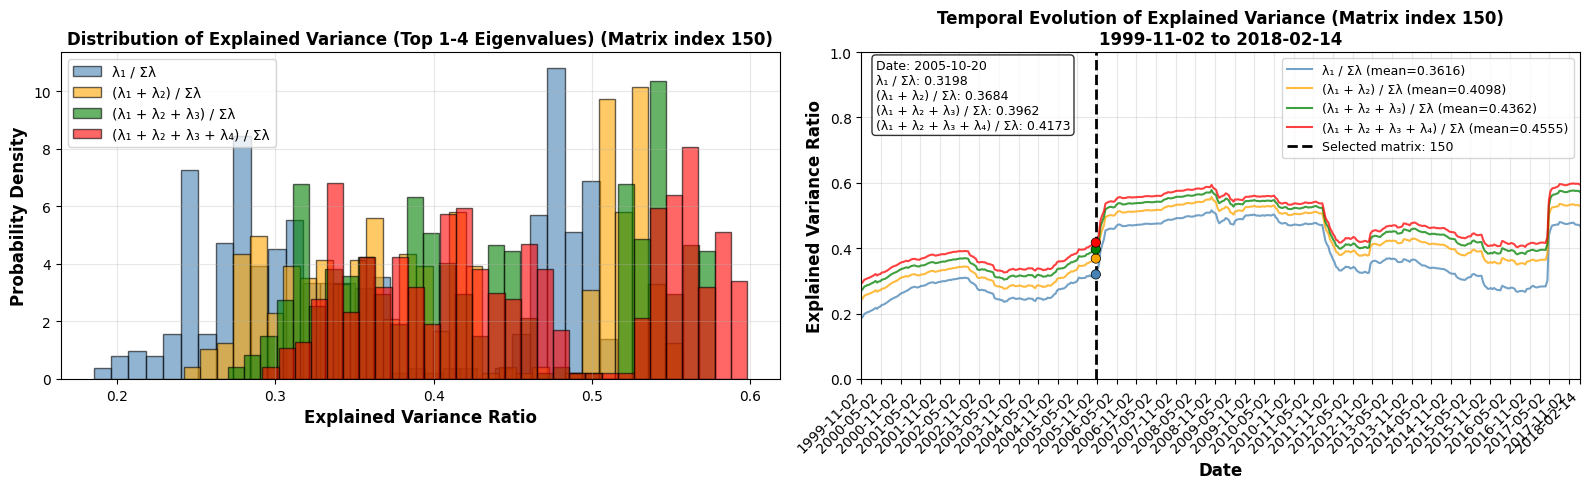


✓ Explained variance analysis complete!


In [59]:
# Compute cumulative explained variance for top-4 eigenvalues
def compute_explained_variance_top4(eigenvalues_np):
    """
    Compute the cumulative explained variance for the top 4 eigenvalues across all matrices.
    
    Parameters:
    -----------
    eigenvalues_np : np.ndarray
        Shape (num_matrices, num_eigenvalues), sorted in descending order
    
    Returns:
    --------
    explained_variance : np.ndarray
        Shape (num_matrices, 4) containing:
        - Column 0: λ₁ / Σλ
        - Column 1: (λ₁ + λ₂) / Σλ
        - Column 2: (λ₁ + λ₂ + λ₃) / Σλ
        - Column 3: (λ₁ + λ₂ + λ₃ + λ₄) / Σλ
    """
    num_matrices = eigenvalues_np.shape[0]
    explained_variance = np.empty((num_matrices, 4))
    
    for i in range(num_matrices):
        eigenvals = eigenvalues_np[i]
        total_sum = np.sum(eigenvals)
        
        # Compute cumulative sums of top 4 eigenvalues, normalized by total sum
        top4_cumsum = np.cumsum(eigenvals[:4])
        explained_variance[i, :] = top4_cumsum / total_sum
    
    return explained_variance


def get_window_reference_dates(window_ranges, timestamps):
    """Map each rolling window to a representative date using the window start date."""
    from datetime import datetime

    ts_dt = [datetime.strptime(ts, '%Y-%m-%d') for ts in timestamps]
    ref_dates = []

    for wr in window_ranges:
        if isinstance(wr, (list, tuple)) and len(wr) >= 2:
            start_idx = int(wr[0])
            ref_idx = start_idx
        else:
            ref_idx = int(wr)

        ref_idx = max(0, min(ref_idx, len(ts_dt) - 1))
        ref_dates.append(ts_dt[ref_idx])

    return ref_dates


explained_variance = compute_explained_variance_top4(eigenvalues_np)
num_windows_ev = explained_variance.shape[0]
selected_indices, selection_label, selection_type = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_windows_ev)

# Build date axis for each rolling window
window_dates = get_window_reference_dates(window_ranges, timestamps)
all_indices = np.arange(num_windows_ev)
all_dates = window_dates
selected_dates = [window_dates[i] for i in selected_indices]
global_start_date = window_dates[0]
global_end_date = window_dates[-1]

print(f"--- Explained Variance by Top-4 Eigenvalues ---\n")
print(f"Total windows analyzed: {explained_variance.shape[0]}")
print(f"Global date range: {global_start_date.strftime('%Y-%m-%d')} to {global_end_date.strftime('%Y-%m-%d')}")
print(f"\nStatistics across all windows:")
print(f"  λ₁ / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 0]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 0]):.4f}")
print(f"    Min:  {np.min(explained_variance[:, 0]):.4f}")
print(f"    Max:  {np.max(explained_variance[:, 0]):.4f}")

print(f"\n  (λ₁ + λ₂) / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 1]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 1]):.4f}")

print(f"\n  (λ₁ + λ₂ + λ₃) / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 2]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 2]):.4f}")

print(f"\n  (λ₁ + λ₂ + λ₃ + λ₄) / Σλ:")
print(f"    Mean: {np.mean(explained_variance[:, 3]):.4f}")
print(f"    Std:  {np.std(explained_variance[:, 3]):.4f}")

# Visualization: Overlaid histograms + temporal evolution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ===== Left Plot: Overlaid Histograms (Density) =====
ax = axes[0]
ax.hist(explained_variance[:, 0], bins=30, density=True, alpha=0.6, 
        label='λ₁ / Σλ', color='steelblue', edgecolor='black')
ax.hist(explained_variance[:, 1], bins=30, density=True, alpha=0.6, 
        label='(λ₁ + λ₂) / Σλ', color='orange', edgecolor='black')
ax.hist(explained_variance[:, 2], bins=30, density=True, alpha=0.6, 
        label='(λ₁ + λ₂ + λ₃) / Σλ', color='green', edgecolor='black')
ax.hist(explained_variance[:, 3], bins=30, density=True, alpha=0.6, 
        label='(λ₁ + λ₂ + λ₃ + λ₄) / Σλ', color='red', edgecolor='black')

ax.set_xlabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax.set_title(f'Distribution of Explained Variance (Top 1-4 Eigenvalues) ({selection_label})', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

# ===== Right Plot: Time Series with date-based X axis =====
ax = axes[1]
series_labels = [
    'λ₁ / Σλ',
    '(λ₁ + λ₂) / Σλ',
    '(λ₁ + λ₂ + λ₃) / Σλ',
    '(λ₁ + λ₂ + λ₃ + λ₄) / Σλ',
]
series_colors = ['steelblue', 'orange', 'green', 'red']

mean_for_legend = np.mean(explained_variance, axis=0) if selection_type == 'all' else None

for i, (label, color) in enumerate(zip(series_labels, series_colors)):
    if mean_for_legend is not None:
        plot_label = f"{label} (mean={mean_for_legend[i]:.4f})"
    else:
        plot_label = label
    ax.plot(all_dates, explained_variance[all_indices, i], alpha=0.75, linewidth=1.5, color=color, label=plot_label)

if selection_type == 'single':
    selected_idx = int(selected_indices[0])
    selected_values = explained_variance[selected_idx, :]
    selected_date = selected_dates[0]

    ax.axvline(
        selected_date,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Selected matrix: {selected_idx}'
    )
    ax.scatter(
        [selected_date] * 4,
        selected_values,
        color=series_colors,
        edgecolor='black',
        linewidth=0.5,
        zorder=6,
        s=45,
    )

    value_text = "\n".join([f"{series_labels[j]}: {selected_values[j]:.4f}" for j in range(4)])
    ax.text(
        0.02,
        0.98,
        f"Date: {selected_date.strftime('%Y-%m-%d')}\n{value_text}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    )

elif selection_type == 'range':
    range_start = selected_dates[0]
    range_end = selected_dates[-1]
    range_means = np.mean(explained_variance[selected_indices], axis=0)

    ax.axvline(
        range_start,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Range start: {range_start.strftime("%Y-%m-%d")}'
    )
    ax.axvline(
        range_end,
        color='dimgray',
        linestyle='--',
        linewidth=2,
        label=f'Range end: {range_end.strftime("%Y-%m-%d")}'
    )
    ax.axvspan(range_start, range_end, color='gray', alpha=0.08)

    for i, (label, color) in enumerate(zip(series_labels, series_colors)):
        ax.plot(
            [range_start, range_end],
            [range_means[i], range_means[i]],
            color=color,
            linestyle=':',
            linewidth=2,
            label=f'Range mean {label}: {range_means[i]:.4f}',
        )

# X ticks: fixed first/last matrix dates + regular 6-month intervals
import calendar

def add_months(dt, months):
    month = dt.month - 1 + months
    year = dt.year + month // 12
    month = month % 12 + 1
    day = min(dt.day, calendar.monthrange(year, month)[1])
    return dt.replace(year=year, month=month, day=day)

tick_dates = [global_start_date]
next_tick = add_months(global_start_date, 6)
while next_tick < global_end_date:
    tick_dates.append(next_tick)
    next_tick = add_months(next_tick, 6)
tick_dates.append(global_end_date)
ax.set_xlim(global_start_date, global_end_date)
ax.set_xticks(tick_dates)
ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in tick_dates], rotation=45, ha='right')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax.set_title(
    f'Temporal Evolution of Explained Variance ({selection_label})\n'
    f'{global_start_date.strftime("%Y-%m-%d")} to {global_end_date.strftime("%Y-%m-%d")}',
    fontsize=12,
    fontweight='bold'
)
ax.set_ylim(0, 1)
series_means_for_legend = np.mean(explained_variance, axis=0)
handles, legend_labels = ax.get_legend_handles_labels()
for i, base_label in enumerate(series_labels):
    if i < len(legend_labels):
        legend_labels[i] = f'{base_label} (mean={series_means_for_legend[i]:.4f})'
filtered_legend = [
    (h, l) for h, l in zip(handles, legend_labels)
    if not l.startswith('Range mean ')
]
if filtered_legend:
    handles, legend_labels = zip(*filtered_legend)
ax.legend(handles, legend_labels, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure
plot_path = RESULTS_FOLDER / '2c_explained_variance_top4.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Plot saved to: {plot_path}")

plt.show()

print(f"\n✓ Explained variance analysis complete!")


Additional Spectral Diagnostic A: Cumulative Explained Variance
Selection: Matrix index 150
Cumulative variance threshold: 75.00%
k from mean cumulative curve: 83
Average k across selected matrices: 83.00
Automatically selected k (ceil of average): 83
✓ Plot saved to: ..\results\data_00_20_w724_s10\matrix_150\2d_cumulative_explained_variance_75.00%.png


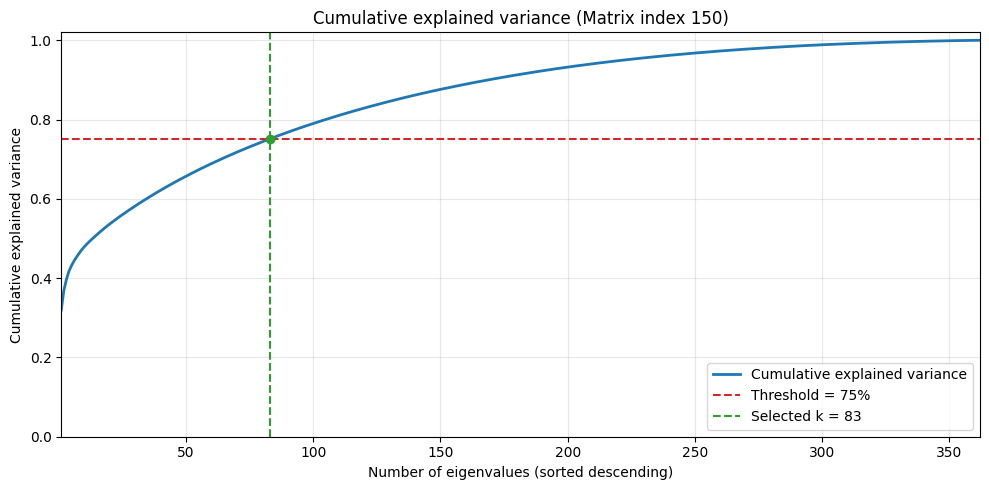

In [60]:
CUMULATIVE_VARIANCE_THRESHOLD = 0.75  # target retained cumulative variance in (0, 1]

if not (0.0 < CUMULATIVE_VARIANCE_THRESHOLD <= 1.0):
    raise ValueError("CUMULATIVE_VARIANCE_THRESHOLD must be in (0, 1].")

# Reuse the global selection for consistency with the rest of notebook 03.
selected_indices, selection_label, selection_type = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_windows)
selected_eigenvalues = eigenvalues_tensor[selected_indices]  # descending order from previous eigendecomposition cell

# Clamp tiny negative numerical noise (correlation matrices should be PSD).
selected_eigenvalues = torch.clamp(selected_eigenvalues, min=0.0)

eigvals_sum = selected_eigenvalues.sum(dim=1, keepdim=True)
if torch.any(eigvals_sum <= 0):
    raise ValueError("Found at least one matrix with non-positive eigenvalue sum in selected set.")

explained_var_ratio = selected_eigenvalues / eigvals_sum
cum_explained_var = torch.cumsum(explained_var_ratio, dim=1)
mean_cum_explained_var = cum_explained_var.mean(dim=0)
mean_curve_np = mean_cum_explained_var.cpu().numpy()
threshold = float(CUMULATIVE_VARIANCE_THRESHOLD)

k_from_mean_curve = int(np.searchsorted(mean_curve_np, threshold, side="left") + 1)
k_from_mean_curve = min(max(k_from_mean_curve, 1), num_assets)

threshold_mask = cum_explained_var >= threshold
k_per_matrix = threshold_mask.float().argmax(dim=1) + 1
k_mean_per_matrix = float(k_per_matrix.float().mean().item())
k_selected = int(np.ceil(k_mean_per_matrix))
k_selected = min(max(k_selected, 1), num_assets)

print("\n" + "=" * 60)
print("Additional Spectral Diagnostic A: Cumulative Explained Variance")
print("=" * 60)
print(f"Selection: {selection_label}")
print(f"Cumulative variance threshold: {threshold:.2%}")
print(f"k from mean cumulative curve: {k_from_mean_curve}")
print(f"Average k across selected matrices: {k_mean_per_matrix:.2f}")
print(f"Automatically selected k (ceil of average): {k_selected}")

is_multi_matrix_selection = selected_eigenvalues.shape[0] > 1
curve_label = "Mean cumulative explained variance" if is_multi_matrix_selection else "Cumulative explained variance"
y_axis_label = "Mean cumulative explained variance" if is_multi_matrix_selection else "Cumulative explained variance"
plot_title = (
    f"Mean cumulative explained variance ({selection_label})"
    if is_multi_matrix_selection
    else f"Cumulative explained variance ({selection_label})"
)

x = np.arange(1, num_assets + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, mean_curve_np, linewidth=2.0, label=curve_label)
ax.axhline(y=threshold, color="tab:red", linestyle="--", label=f"Threshold = {threshold:.0%}")
ax.axvline(x=k_selected, color="tab:green", linestyle="--", label=f"Selected k = {k_selected}")
ax.scatter([k_selected], [mean_curve_np[k_selected - 1]], color="tab:green", zorder=3)
ax.set_xlabel("Number of eigenvalues (sorted descending)")
ax.set_ylabel(y_axis_label)
ax.set_title(plot_title)
ax.set_ylim(0, 1.02)
ax.set_xlim(1, num_assets)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

plot_path = RESULTS_FOLDER / f"2d_cumulative_explained_variance_{CUMULATIVE_VARIANCE_THRESHOLD:.2%}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"✓ Plot saved to: {plot_path}")
plt.show()

### Property 3: The Perron-Frobenius property holds true (first eigenvector has positive entries and has multiplicity one)


Perron-Frobenius Property Analysis

Matrix #150:
  Perron-Frobenius property satisfied: True
  Largest eigenvalue multiplicity: 1
  Min component: 0.007502, Max component: 0.074979

No tickers with negative values

✓ Plot saved to: ..\results\data_00_20_w724_s10\matrix_150\3_eigenvector1.png


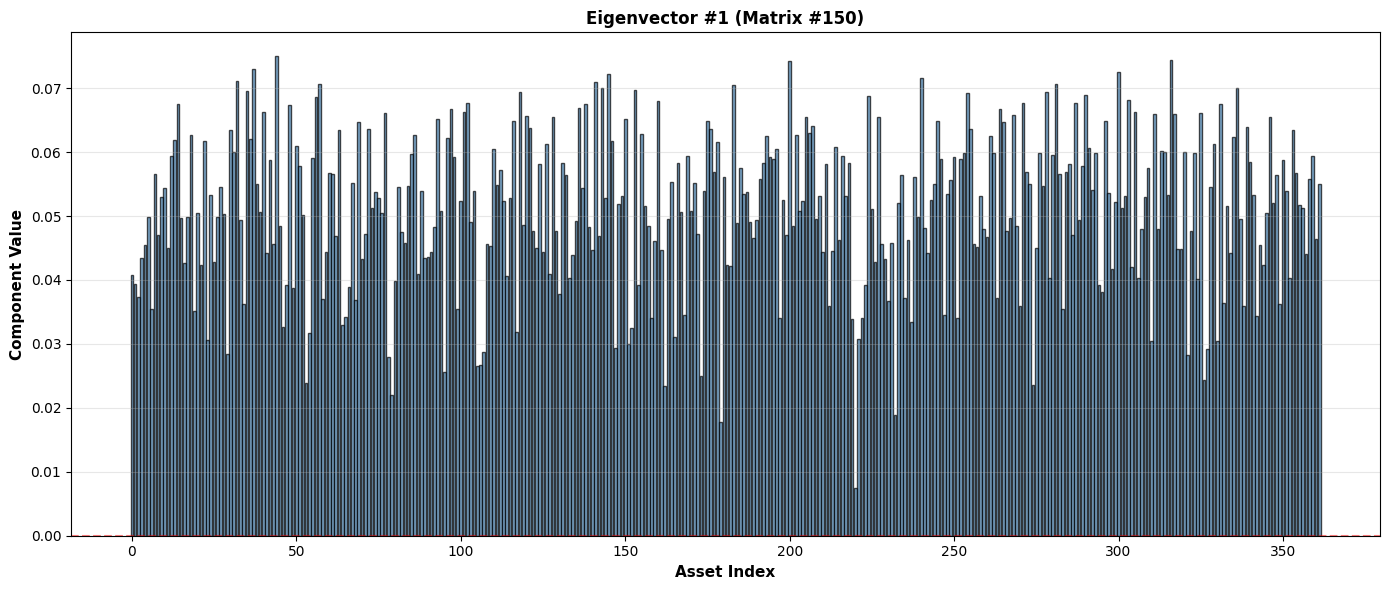


Eigenvector #2 Analysis

Eigenvector #2 (Matrix #150):
  Eigenvalue: 17.580864
  Min component: -0.101422, Max component: 0.172760

Tickers with POSITIVE components (204 total):
    0. AAPL   -> 0.039489
    1. ABC    -> 0.005577
    2. ABMD   -> 0.005664
    4. ADBE   -> 0.021364
    6. ADM    -> 0.079561
    8. ADSK   -> 0.018643
    9. AEE    -> 0.048251
   10. AEP    -> 0.047737
   11. AES    -> 0.075170
   16. AKAM   -> 0.031876
   17. ALB    -> 0.054361
   19. ALXN   -> 0.021963
   20. AMAT   -> 0.004579
   22. AME    -> 0.027609
   23. AMGN   -> 0.031889
   24. AMT    -> 0.045494
   25. AMZN   -> 0.012281
   26. ANSS   -> 0.020742
   29. APA    -> 0.172760
   30. APD    -> 0.068303
   31. APH    -> 0.034861
   33. ATO    -> 0.059006
   34. ATVI   -> 0.024673
   36. AVY    -> 0.018905
   39. BA     -> 0.021018
   41. BAX    -> 0.012331
   43. BDX    -> 0.023700
   45. BF-B   -> 0.018827
   46. BIIB   -> 0.021317
   47. BIO    -> 0.005996
   49. BKNG   -> 0.010870
   51. BLL    -

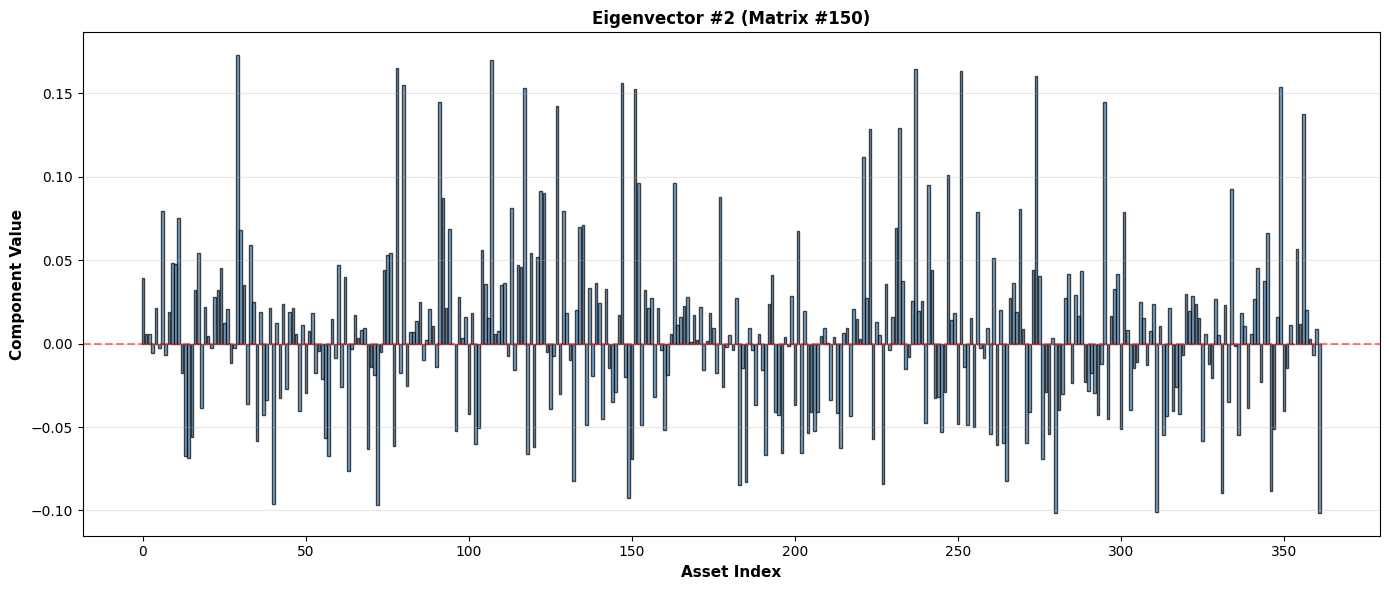


Eigenvector #3 Analysis

Eigenvector #3 (Matrix #150):
  Eigenvalue: 10.095474
  Min component: -0.180510, Max component: 0.090792

Tickers with POSITIVE components (205 total):
    0. AAPL   -> 0.053620
    2. ABMD   -> 0.012507
    4. ADBE   -> 0.013717
    5. ADI    -> 0.050107
    6. ADM    -> 0.019671
    8. ADSK   -> 0.039141
   16. AKAM   -> 0.073612
   17. ALB    -> 0.023227
   19. ALXN   -> 0.011724
   20. AMAT   -> 0.050736
   21. AMD    -> 0.074892
   22. AME    -> 0.070280
   24. AMT    -> 0.041108
   25. AMZN   -> 0.026527
   26. ANSS   -> 0.046878
   28. AOS    -> 0.024120
   29. APA    -> 0.041210
   30. APD    -> 0.028882
   31. APH    -> 0.053021
   34. ATVI   -> 0.026115
   36. AVY    -> 0.021470
   38. AZO    -> 0.010886
   39. BA     -> 0.038293
   40. BAC    -> 0.002872
   42. BBY    -> 0.030398
   44. BEN    -> 0.015699
   49. BKNG   -> 0.034927
   50. BLK    -> 0.041431
   51. BLL    -> 0.043423
   53. BRK.B  -> 0.028282
   54. BSX    -> 0.007288
   55. BWA    -

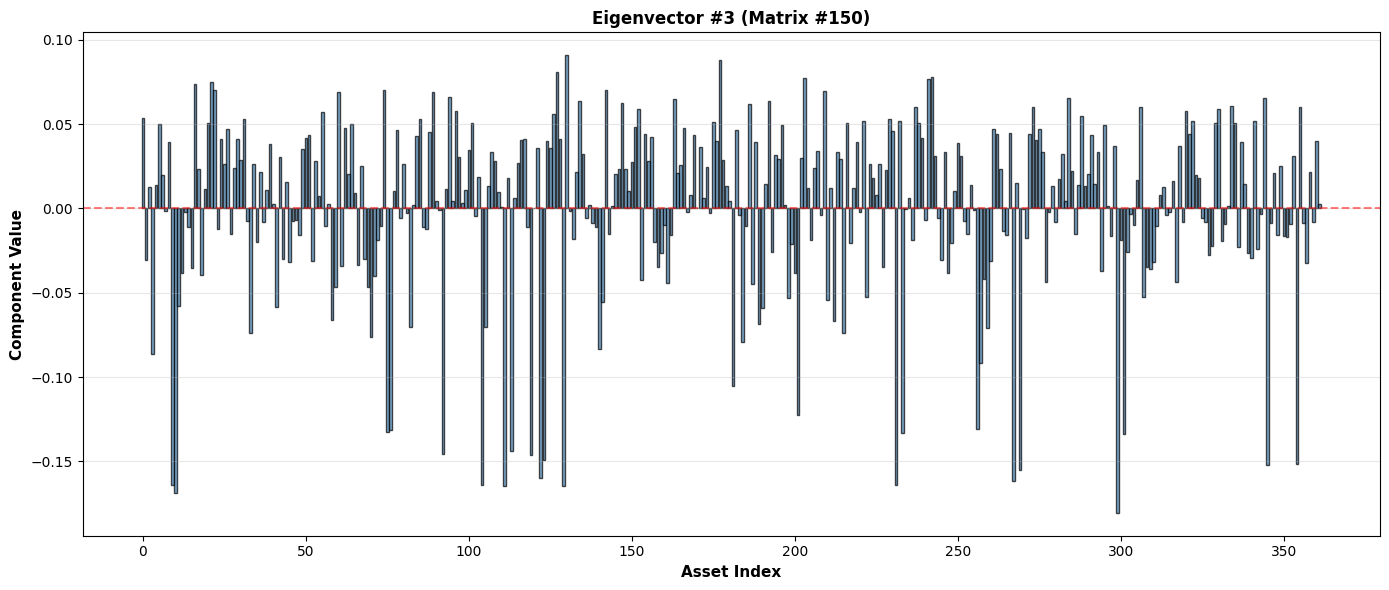

In [61]:
eigenvalues_np = eigenvalues_tensor.cpu().numpy()
eigenvectors_np = eigenvectors_tensor.cpu().numpy()

num_matrices = eigenvalues_np.shape[0]
num_assets = eigenvalues_np.shape[1]

# Parse global selection to determine analysis type and matrices
matrix_indices, _, analysis_type = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_matrices)

# Pre-compute eigenvectors and properties for ALL matrices
pf_property_check = np.zeros(num_matrices, dtype=bool)
first_eigenvectors = np.full((num_assets, num_matrices), np.nan)
max_eigenvalue_multiplicity = np.zeros(num_matrices, dtype=int)

for i in range(num_matrices):
    eigenvalues = eigenvalues_np[i]
    eigenvectors = eigenvectors_np[i]

    # Get first eigenvector (largest eigenvalue)
    first_eigenvector = eigenvectors[:, 0].copy()

    # Normalize sign using sum (more robust than first element)
    if np.sum(first_eigenvector) < 0:
        first_eigenvector = -first_eigenvector

    first_eigenvectors[:, i] = first_eigenvector
    pf_property_check[i] = np.all(first_eigenvector >= -1e-2)
    max_eigenvalue_multiplicity[i] = np.sum(np.isclose(eigenvalues[0], eigenvalues, atol=1e-6))



def print_negative_tickers(vector, tickers, use_mean_label):
    neg_idx = np.where(vector < 0)[0]
    if len(neg_idx) > 0:
        label = 'mean component' if use_mean_label else 'components'
        print(f"\nTickers with NEGATIVE {label} ({len(neg_idx)} total):")
        for idx in neg_idx:
            print(f"  {idx:3d}. {tickers[idx]:6s} -> {vector[idx]:8.6f}")
    else:
        print("\nNo tickers with negative values")

def print_positive_tickers(vector, tickers, use_mean_label):
    pos_idx = np.where(vector > 0)[0]
    if len(pos_idx) > 0:
        label = 'mean component' if use_mean_label else 'components'
        print(f"\nTickers with POSITIVE {label} ({len(pos_idx)} total):")
        for idx in pos_idx:
            print(f"  {idx:3d}. {tickers[idx]:6s} -> {vector[idx]:8.6f}")
    else:
        print("\nNo tickers with positive values")

def plot_property3_single(eigvec, title):
    """Render a simple histogram for a single matrix eigenvector."""
    fig, ax = plt.subplots(figsize=(14, 6))
    asset_idx = np.arange(num_assets)
    
    ax.bar(asset_idx, eigvec, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Asset Index', fontsize=11, fontweight='bold')
    ax.set_ylabel('Component Value', fontsize=11, fontweight='bold')
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

def plot_property3_panels(first_panel_data, first_panel_title, mean_vec, std_vec, second_panel_title):
    """Render the two required plots for Property 3 without duplicating plotting code."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    asset_idx = np.arange(num_assets)

    # First panel: always overlay.
    for vec in first_panel_data:
        axes[0].plot(vec, alpha=0.3)

    axes[0].set_title(first_panel_title, fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Asset Index', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Component Value', fontsize=11, fontweight='bold')
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[0].grid(True, alpha=0.3, axis='y')

    # Second panel: always mean ± std.
    axes[1].bar(asset_idx, mean_vec, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].fill_between(asset_idx, mean_vec - std_vec, mean_vec + std_vec, alpha=0.3, color='steelblue')
    axes[1].set_title(second_panel_title, fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Asset Index', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Mean Value', fontsize=11, fontweight='bold')
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig

# ===== ANALYSIS OUTPUT =====
print(f"\n{'='*60}")
print("Perron-Frobenius Property Analysis")
print(f"{'='*60}")

subset_indices = matrix_indices
subset_vec = first_eigenvectors[:, subset_indices]
subset_pf = pf_property_check[subset_indices]
subset_mult = max_eigenvalue_multiplicity[subset_indices]
num_selected = len(subset_indices)
num_satisfying = np.sum(subset_pf)

if analysis_type == 'single':
    matrix_idx = subset_indices[0]
    eigvec = subset_vec[:, 0]

    print(f"\nMatrix #{matrix_idx}:")
    print(f"  Perron-Frobenius property satisfied: {subset_pf[0]}")
    print(f"  Largest eigenvalue multiplicity: {int(subset_mult[0])}")
    print(f"  Min component: {np.min(eigvec):.6f}, Max component: {np.max(eigvec):.6f}")

    print_negative_tickers(eigvec, tickers, use_mean_label=False)
    
    fig = plot_property3_single(eigvec, f'Eigenvector #1 (Matrix #{matrix_idx})')
    
    # Save the figure
    plot_path = RESULTS_FOLDER / '3_eigenvector1.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Plot saved to: {plot_path}")
    
    plt.show()

    # ===== SECOND AND THIRD EIGENVECTORS =====
    for eig_idx in [1, 2]:
        if eig_idx < num_assets:
            print(f"\n{'='*60}")
            print(f"Eigenvector #{eig_idx + 1} Analysis")
            print(f"{'='*60}")
            
            # Extract eigenvector from original tensor
            eigenvector_full = eigenvectors_np[matrix_idx, :, eig_idx].copy()
            
            # Normalize sign using sum (consistent with first eigenvector)
            if np.sum(eigenvector_full) < 0:
                eigenvector_full = -eigenvector_full
            
            # Get eigenvalue
            eigenvalue = eigenvalues_np[matrix_idx, eig_idx]
            
            print(f"\nEigenvector #{eig_idx + 1} (Matrix #{matrix_idx}):")
            print(f"  Eigenvalue: {eigenvalue:.6f}")
            print(f"  Min component: {np.min(eigenvector_full):.6f}, Max component: {np.max(eigenvector_full):.6f}")
            
            print_positive_tickers(eigenvector_full, tickers, use_mean_label=False)
            
            fig = plot_property3_single(eigenvector_full, f'Eigenvector #{eig_idx + 1} (Matrix #{matrix_idx})')
            
            # Save the figure
            plot_path = RESULTS_FOLDER / f'3_eigenvector{eig_idx + 1}.png'
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            print(f"\n✓ Plot saved to: {plot_path}")
            
            plt.show()

else:
    mean_vec = np.mean(subset_vec, axis=1)
    std_vec = np.std(subset_vec, axis=1)

    if analysis_type == 'all':
        print(f"\nMatrices satisfying Perron-Frobenius property: {num_satisfying}/{num_matrices} ({100*num_satisfying/num_matrices:.1f}%)")
        print(f"All matrices have multiplicity = 1: {np.all(subset_mult == 1)}")
        first_panel_title = 'Eigenvector #1 (All Matrices)'
        second_panel_title = 'Mean Eigenvector #1 ± Std Dev (All Matrices)'
    else:
        print(f"\nMatrices #{subset_indices[0]} to #{subset_indices[-1]} ({num_selected} total)")
        print(f"Satisfying Perron-Frobenius property: {num_satisfying}/{num_selected} ({100*num_satisfying/num_selected:.1f}%)")
        print(f"All selected matrices have multiplicity = 1: {np.all(subset_mult == 1)}")
        first_panel_title = f'Eigenvector #1 (Matrices #{subset_indices[0]}-#{subset_indices[-1]})'
        second_panel_title = f'Mean Eigenvector #1 ± Std Dev (Matrices #{subset_indices[0]}-#{subset_indices[-1]})'

    print_negative_tickers(mean_vec, tickers, use_mean_label=True)

    first_panel_data = [subset_vec[:, j] for j in range(num_selected)]

    fig = plot_property3_panels(
        first_panel_data=first_panel_data,
        first_panel_title=first_panel_title,
        mean_vec=mean_vec,
        std_vec=std_vec,
        second_panel_title=second_panel_title,
    )
    
    # Save the figure
    plot_path = RESULTS_FOLDER / '3_eigenvector1.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Plot saved to: {plot_path}")
    
    plt.show()

### Property 4: Correlations have a hierarchical structure

For a **single selected correlation matrix**, we visualize:
- the correlation matrix heatmap
- the hierarchical clustering dendrogram built from the distance matrix

Distance is computed from correlation as:

$$
d_{ij} = \sqrt{2(1 - \rho_{ij})}
$$

✓ Clustered heatmap saved to: ..\results\data_00_20_w724_s10\matrix_150\4a_corr_matrix_clustermap.png


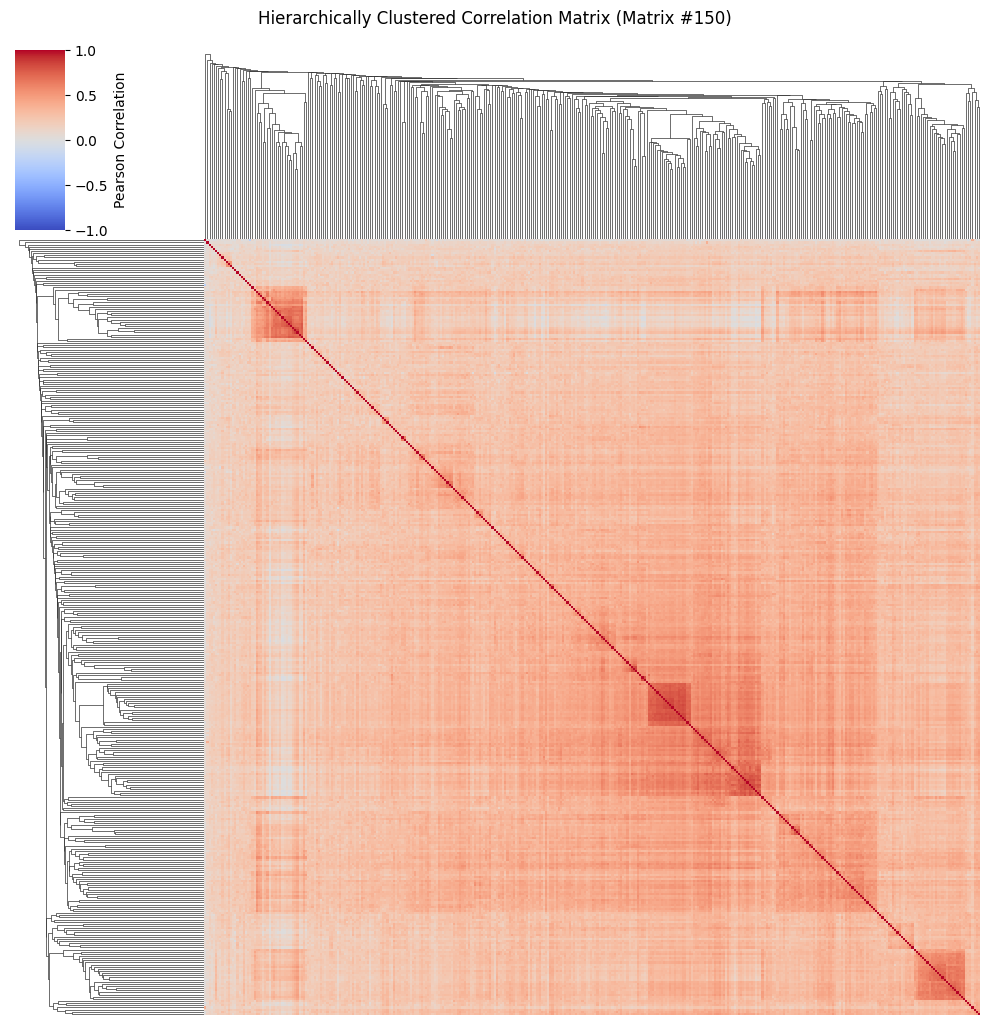

✓ Dendrogram saved to: ..\results\data_00_20_w724_s10\matrix_150\4b_dendrogram.png


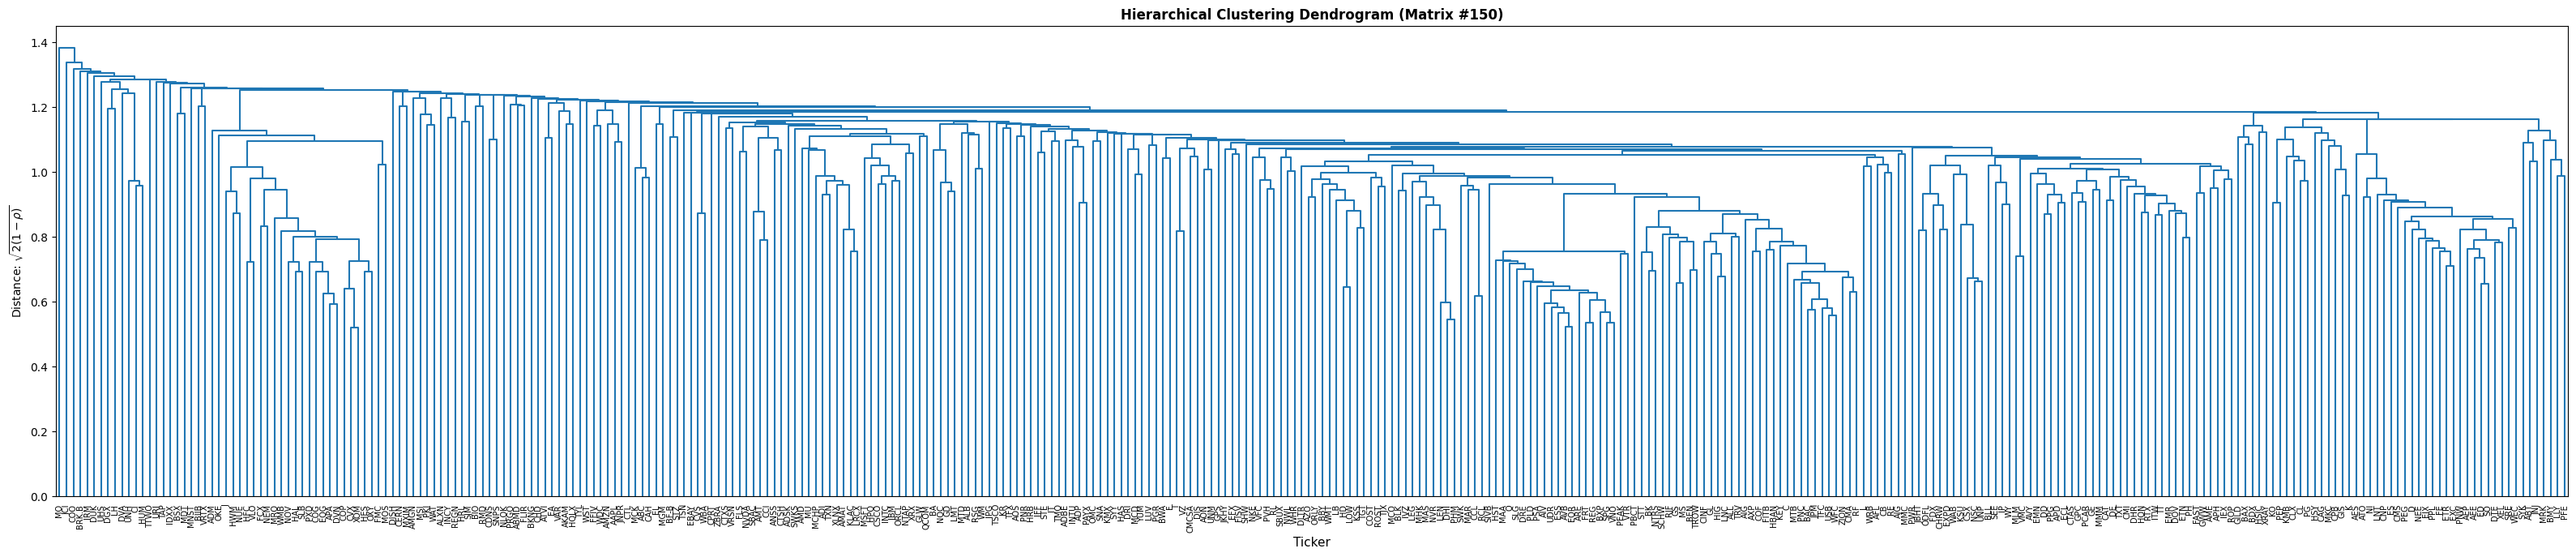

In [62]:
# Property 4 is evaluated only when a single matrix is selected
if SELECTED_CORR_MATRIX == 'all' or (isinstance(SELECTED_CORR_MATRIX, str) and ':' in SELECTED_CORR_MATRIX):
    print("Property 4 is available only for a single matrix selection.")
    print("Set SELECTED_CORR_MATRIX to a zero-based integer index (e.g., 0).")
else:
    try:
        from scipy.cluster.hierarchy import linkage, dendrogram
        from scipy.spatial.distance import squareform
    except ImportError as exc:
        raise ImportError(
            "SciPy is required for Property 4. Install it with: pip install scipy"
        ) from exc

    matrix_idx = int(SELECTED_CORR_MATRIX)
    if not (0 <= matrix_idx < corr_tensor.shape[0]):
        raise ValueError(
            f"Invalid SELECTED_CORR_MATRIX index: {matrix_idx}. Valid zero-based range is [0, {corr_tensor.shape[0] - 1}]."
        )

    # Extract and sanitize the selected correlation matrix
    corr_matrix = extract_and_sanitize_correlation_matrix(corr_tensor, matrix_idx)

    # Build distance matrix from correlations: d = sqrt(2 * (1 - corr))
    dist_matrix = build_distance_matrix(corr_matrix)

    # Convert to condensed form and compute hierarchical linkage
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method='average')

    labels = tickers if len(tickers) == corr_matrix.shape[0] else [f"A{i}" for i in range(corr_matrix.shape[0])]

    # ===== Figure 1: Hierarchically clustered correlation matrix  =====
    g_corr = sns.clustermap(
        corr_matrix,
        row_linkage=Z,
        col_linkage=Z,
        vmin=-1,
        vmax=1,
        cmap='coolwarm',
        linewidths=0,
        figsize=(10, 10),
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': 'Pearson Correlation'},
    )
    g_corr.figure.suptitle(f'Hierarchically Clustered Correlation Matrix (Matrix #{matrix_idx})', y=1.02)
    clustermap_path = RESULTS_FOLDER / '4a_corr_matrix_clustermap.png'
    g_corr.figure.savefig(clustermap_path, dpi=150, bbox_inches='tight')
    print(f"✓ Clustered heatmap saved to: {clustermap_path}")
    plt.show()

    # ===== Figure 2: Hierarchical Dendrogram =====
    fig, ax = plt.subplots(figsize=(40, 10))
    single_color = 'tab:blue'
    dendrogram(
        Z,
        labels=labels,
        leaf_rotation=90,
        leaf_font_size=7,
        ax=ax,
        color_threshold=0,
        above_threshold_color=single_color,
        link_color_func=lambda _: single_color,
    )
    ax.set_title(f'Hierarchical Clustering Dendrogram (Matrix #{matrix_idx})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Ticker', fontsize=11)
    ax.set_ylabel(r'Distance: $\sqrt{2(1-\rho)}$')

    # Keep all tickers visible and reserve extra space for rotated labels.
    fig.subplots_adjust(bottom=0.3)

    dendrogram_path = RESULTS_FOLDER / '4b_dendrogram.png'
    plt.savefig(dendrogram_path, dpi=300, bbox_inches='tight')
    print(f"✓ Dendrogram saved to: {dendrogram_path}")
    plt.show()


### Property 5: The Minimum Spanning Tree (MST) obtained from a correlation matrix satisfies the scale-free property

We test whether node degrees in MSTs extracted from correlation matrices show a scale-free behavior by analyzing the degree-frequency distribution in log-log scale.

For each selected matrix, we:
- convert correlations into distances
- compute the MST
- count node degrees
- average degree frequencies across selected matrices

#### MST Degree Distribution: Mathematical Summary

##### 1. The Sum of Degrees in a Tree
In graph theory, the **Handshaking Lemma** states that the sum of degrees of all nodes is equal to twice the number of edges:
$$\sum_{i=1}^{N} \deg_i = 2|E|$$

For a **Minimum Spanning Tree (MST)** with $N$ nodes, the number of edges is strictly fixed at:
$$|E| = N - 1$$

Consequently, the sum of all degrees in an MST is always a constant relative to the number of nodes:
$$\sum_{i=1}^{N} \deg_i = 2(N - 1)$$

---

##### 2. Degree Frequency $f(k)$ and Percentage of Nodes
For a given degree $k$, we first compute the normalized frequency used in the analysis:
$$f(k) = \frac{n_k}{N - 1}$$

Where:
*   $n_k$: Number of nodes with degree $k$.
*   $N$: Total number of nodes (assets).

To make interpretation immediate, we also convert this quantity into the **percentage of nodes** with degree $k$:
$$p(k) = 100 \cdot \frac{n_k}{N} = 100 \cdot f(k) \cdot \frac{N - 1}{N}$$

In the output table and in the plot, the y-axis is shown as $p(k)$ (percentage of nodes), so it is directly readable as "what fraction of nodes has degree $k$".

The normalization by $N-1$ for $f(k)$ reflects the structural constraint of the tree's edges, while using $N$ for $p(k)$ provides a standard probability distribution across the total population of nodes. Essentially, the first tracks the density of connections within the MST, whereas the second offers an intuitive percentage for statistical interpretation.

---

##### 3. Connectivity Invariant
Using the $f(k)$ normalization, the weighted sum by degree remains:
$$\sum_{k} (f(k) \times k) = \sum_{k} \left( \frac{n_k \times k}{N - 1} \right) = \frac{2(N - 1)}{N - 1} = 2$$

This value (**2**) is a topological invariant for any tree structure when normalized by its edges, reflecting that each edge contributes exactly two degree units to the system.


Property 5: MST Scale-Free Check
Selection: Matrix index 150
Matrices analyzed: 1
Assets per matrix: 362
Non-zero degree frequencies: 12

Degree-Frequency Table:
Degree     f(k)            Nodes %      Log10(Degree)   Log10(Nodes %) 
------------------------------------------------------------------------
1          0.603878        60.221       0.000000        1.779748       
2          0.202216        20.166       0.301030        1.304614       
3          0.063712        6.354        0.477121        0.803019       
4          0.047091        4.696        0.602060        0.671740       
5          0.038781        3.867        0.698970        0.587419       
6          0.016620        1.657        0.778151        0.219443       
7          0.016620        1.657        0.845098        0.219443       
9          0.002770        0.276        0.954243        -0.558709      
10         0.002770        0.276        1.000000        -0.558709      
14         0.002770        0.276        1.14

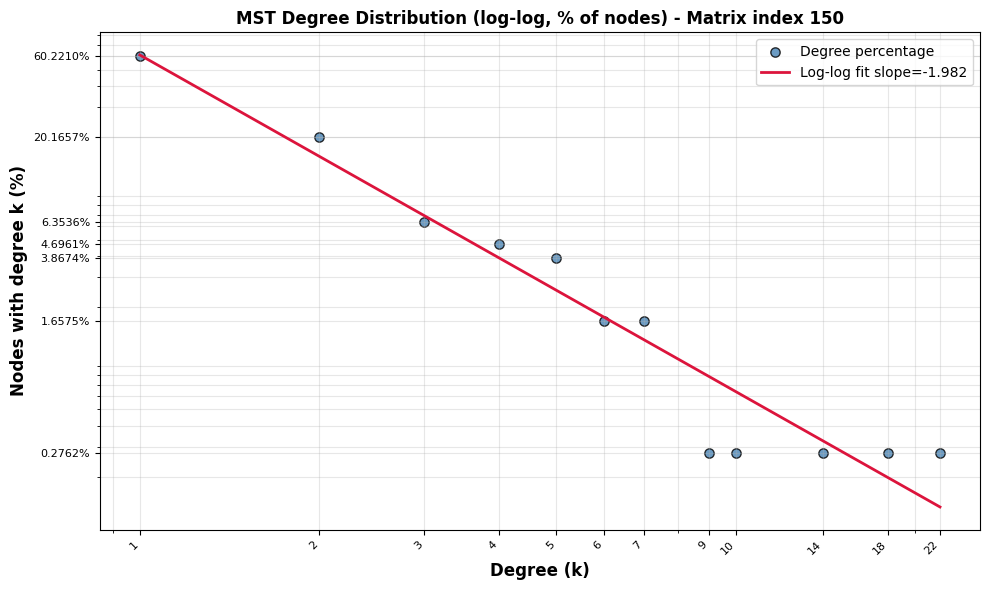

In [63]:
# Property 5: scale-free behavior of MST degree distribution
import networkx as nx


def compute_mst_degree_frequencies(corr_matrices):
    """
    Compute normalized degree frequencies for MSTs built from correlation matrices.

    Returns
    -------
    list of np.ndarray
        Each element contains degree frequencies for one matrix,
        normalized by (num_assets - 1).
    """
    num_matrices, num_assets, _ = corr_matrices.shape
    all_counts = []

    for i in range(num_matrices):
        # Extract and sanitize the correlation matrix
        corr = extract_and_sanitize_correlation_matrix(corr_matrices, i)

        # Build distance matrix from correlations
        dist = build_distance_matrix(corr)

        # Build graph and compute MST using networkx
        G = nx.from_numpy_array(dist)
        mst = nx.minimum_spanning_tree(G)

        # Count degrees in the MST
        degree_counts = {i: 0 for i in range(num_assets)}
        for edge in mst.edges():
            degree_counts[edge[0]] += 1
            degree_counts[edge[1]] += 1

        # Create degree frequency array
        degrees = np.array([degree_counts[i] for i in range(num_assets)])
        unique_degrees, degree_freqs = np.unique(degrees, return_counts=True)

        counts = np.zeros(num_assets)
        for deg, freq in zip(unique_degrees, degree_freqs):
            counts[deg] = freq

        all_counts.append(counts / (num_assets - 1))

    return all_counts


# Select matrices according to the global selection
num_matrices = corr_tensor.shape[0]
selected_indices, selection_label, _ = parse_selected_corr_matrix(SELECTED_CORR_MATRIX, num_matrices)
selected_corr = corr_tensor[selected_indices].cpu().numpy()

# Compute and average degree frequencies
degree_freq = compute_mst_degree_frequencies(selected_corr)
mean_counts = np.mean([df for df in degree_freq], axis=0)

# Use only strictly positive frequencies for log-log visualization
degrees = np.arange(0, mean_counts.shape[0])
valid = mean_counts > 0
x = degrees[valid]
y = mean_counts[valid]

# Convert f(k) to percentage of nodes with degree k
num_assets = corr_tensor.shape[1]
scale_to_percentage = ((num_assets - 1) / num_assets) * 100.0
y_percentage = y * scale_to_percentage

print(f"\n{'='*60}")
print("Property 5: MST Scale-Free Check")
print(f"{'='*60}")
print(f"Selection: {selection_label}")
print(f"Matrices analyzed: {len(selected_indices)}")
print(f"Assets per matrix: {corr_tensor.shape[1]}")
print(f"Non-zero degree frequencies: {len(x)}")

# Print degree frequencies
print(f"\nDegree-Frequency Table:")
print(f"{'Degree':<10} {'f(k)':<15} {'Nodes %':<12} {'Log10(Degree)':<15} {'Log10(Nodes %)':<15}")
print("-" * 72)
for deg, freq, pct in zip(x, y, y_percentage):
    print(f"{deg:<10.0f} {freq:<15.6f} {pct:<12.3f} {np.log10(deg):<15.6f} {np.log10(pct):<15.6f}")

# Optional slope estimate in log-log space
if len(x) >= 2:
    slope, intercept = np.polyfit(np.log10(x), np.log10(y_percentage), 1)
    print(f"Estimated log-log slope: {slope:.4f}")
else:
    slope, intercept = np.nan, np.nan
    print("Estimated log-log slope: not available (insufficient non-zero points)")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y_percentage, s=45, alpha=0.8, color='steelblue', edgecolor='black', label='Degree percentage')

if len(x) >= 2:
    y_fit = 10 ** (intercept + slope * np.log10(x))
    ax.plot(x, y_fit, color='crimson', linewidth=2, label=f'Log-log fit slope={slope:.3f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# Show only numeric k values for the points on x-axis
xticks = np.unique(x.astype(int))
xticks = xticks[xticks > 0]
if len(xticks) > 0:
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{int(k)}' for k in xticks], rotation=45, ha='right')

# Show percentage values on y-axis for displayed points
yticks = np.unique(y_percentage)
yticks = yticks[yticks > 0]
if len(yticks) > 0:
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{val:.4f}%' for val in yticks])

ax.set_xlabel('Degree (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('Nodes with degree k (%)', fontsize=12, fontweight='bold')
ax.set_title(f'MST Degree Distribution (log-log, % of nodes) - {selection_label}', fontsize=12, fontweight='bold')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

plt.tight_layout()

plot_path = RESULTS_FOLDER / '5a_mst_scale_free.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Plot saved to: {plot_path}")
plt.show()

Layout used: radial (radial tree)
✓ MST graph saved to: ..\results\data_00_20_w724_s10\matrix_150\5b_mst_graph_tickers.png


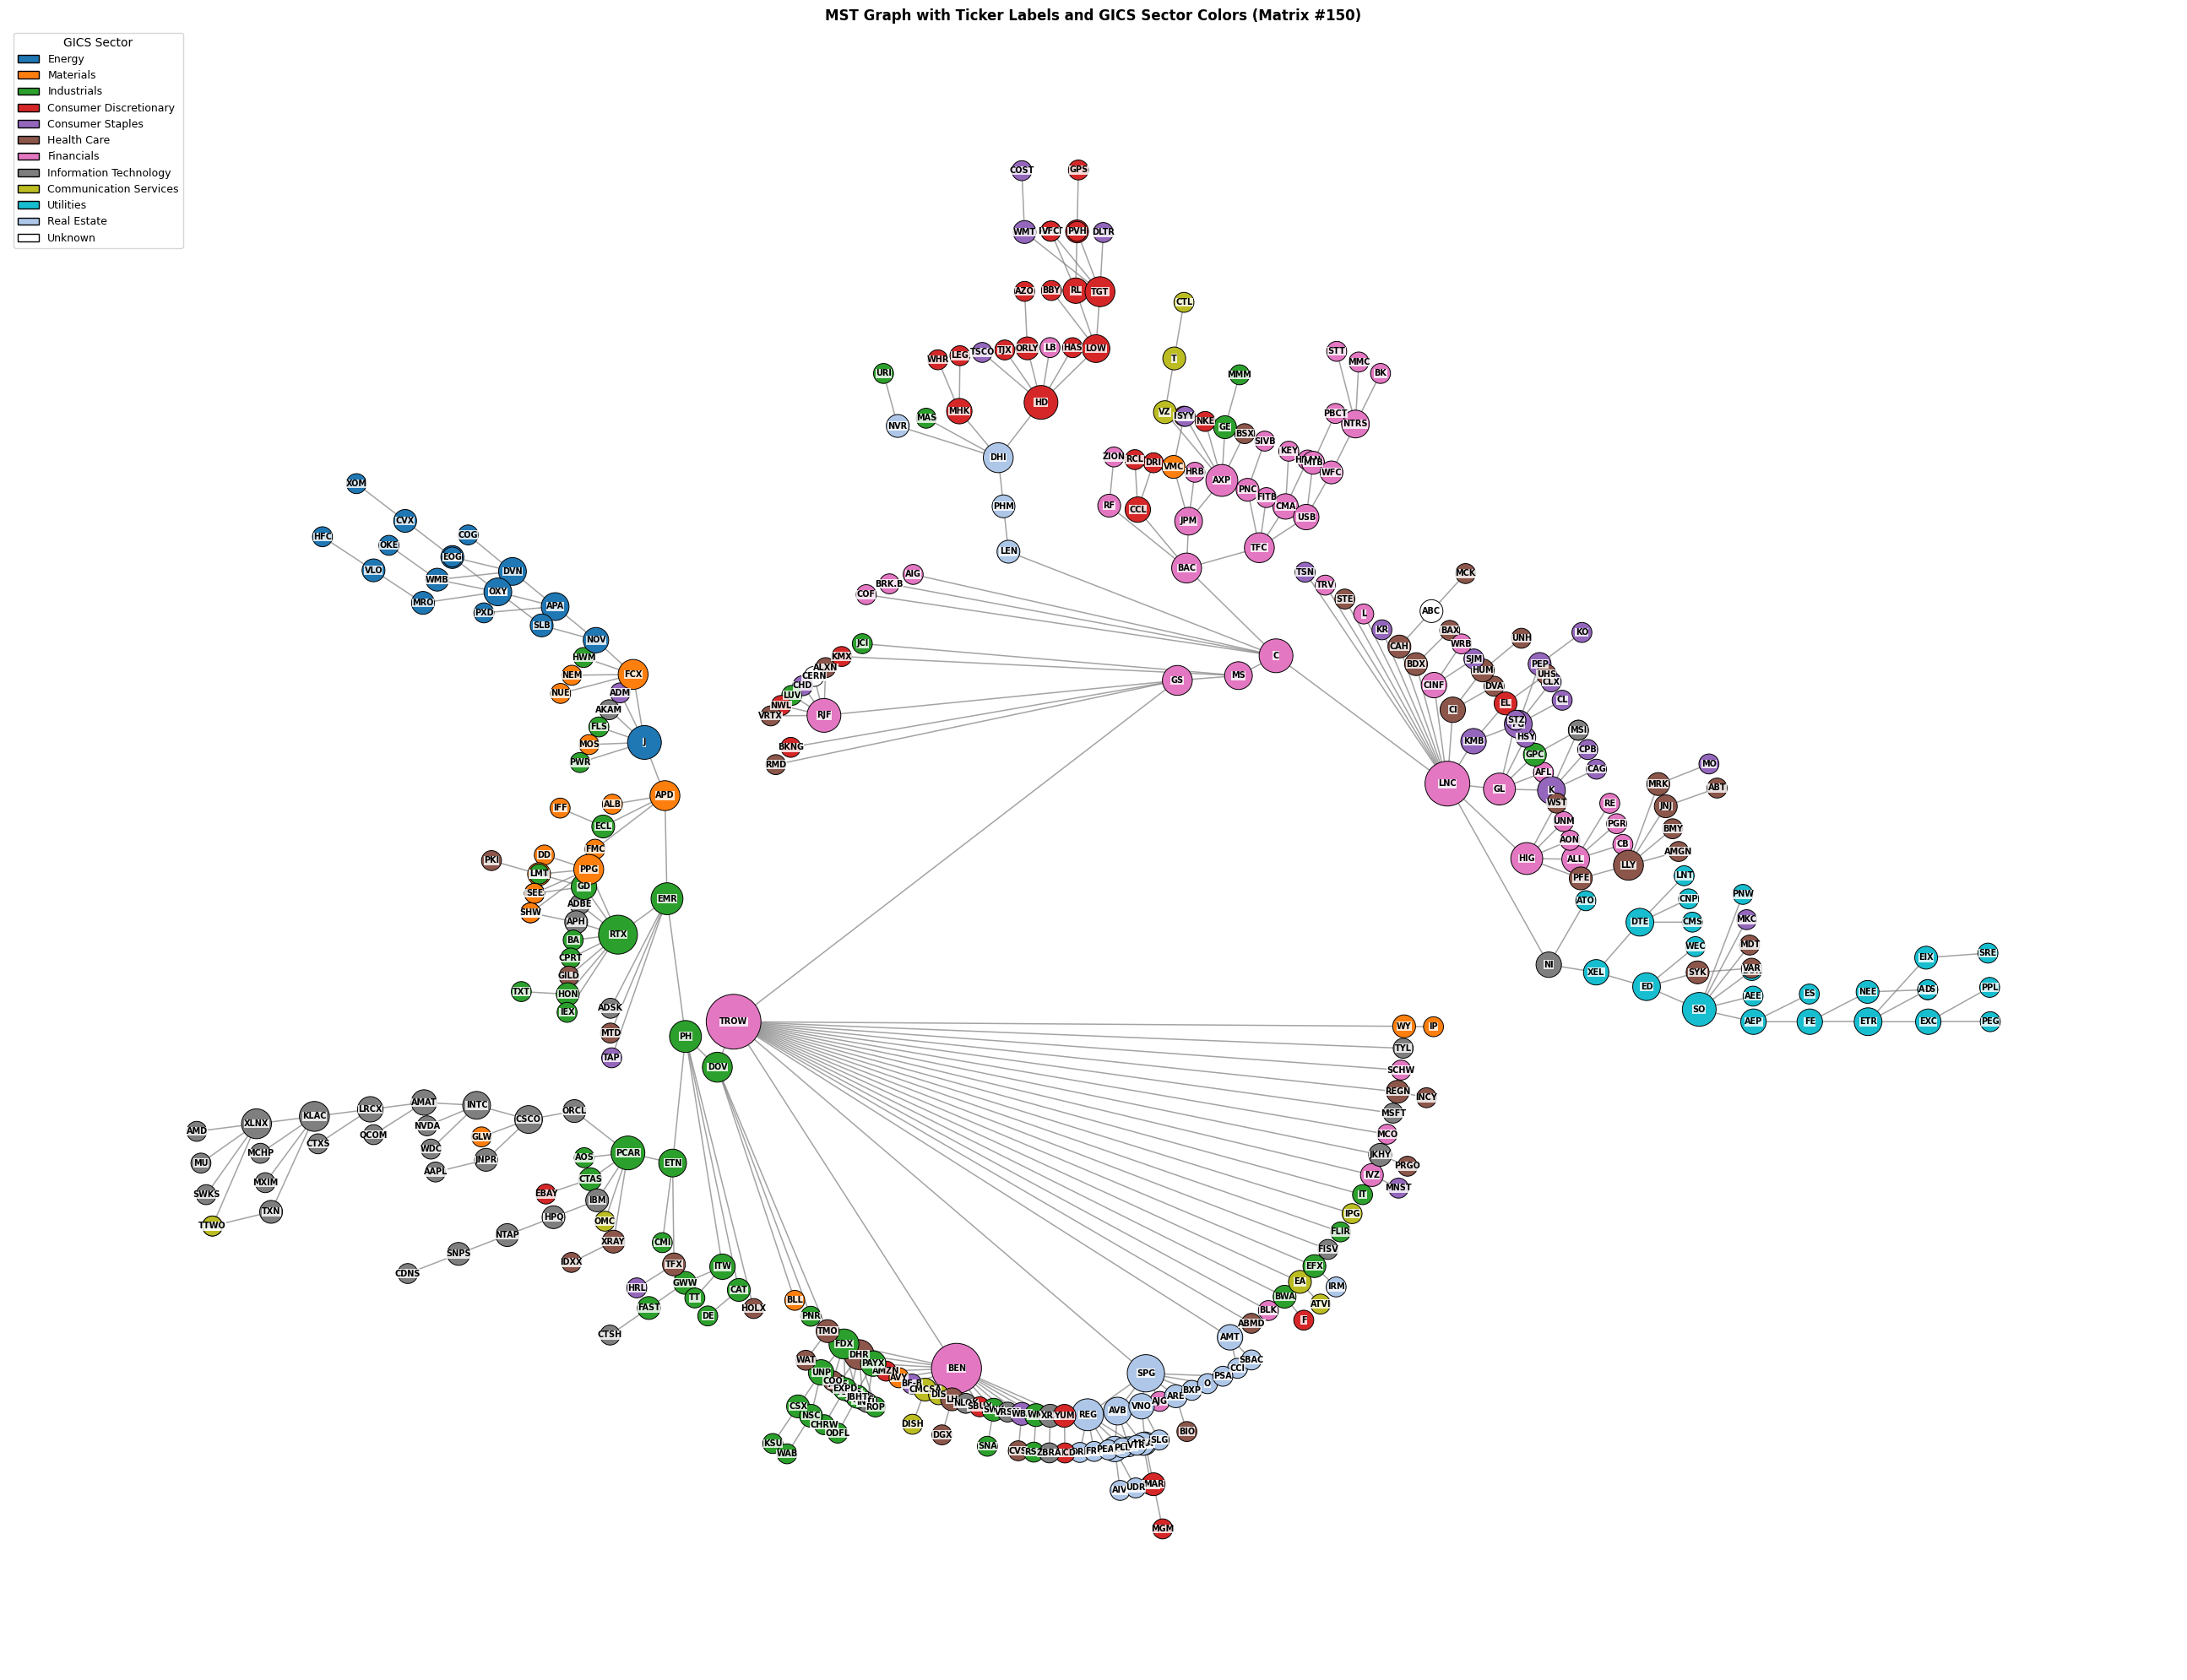

✓ PyVis graph saved to: ..\results\data_00_20_w724_s10\matrix_150\5c_mst_graph_pyvis.html


In [64]:
# Visualize the MST graph with ticker names as node labels
import networkx as nx
from matplotlib.patches import Patch

# Parse selection and require a single matrix for graph visualization
selected_indices, selection_label, selection_type = parse_selected_corr_matrix(
    SELECTED_CORR_MATRIX, corr_tensor.shape[0]
 )

if selection_type != 'single':
    print("MST graph visualization requires a single matrix selection.")
    print("Set SELECTED_CORR_MATRIX to a zero-based integer index (e.g., 0).")
else:
    matrix_idx = int(selected_indices[0])

    # Load GICS sectors from CSV
    gics_path = Path("../results/gics_by_ticker.csv")
    if not gics_path.exists():
        raise FileNotFoundError(f"Missing GICS CSV: {gics_path}")
    gics_df = pd.read_csv(gics_path)
    gics_df["ticker"] = gics_df["ticker"].astype(str).str.upper()
    gics_df["gics_category"] = gics_df["gics_category"].astype(str)
    gics_map = dict(zip(gics_df["ticker"], gics_df["gics_category"]))

    # Build sanitized correlation and distance matrices
    corr_matrix = extract_and_sanitize_correlation_matrix(corr_tensor, matrix_idx)
    dist_matrix = build_distance_matrix(corr_matrix)

    # Build full graph and extract its minimum spanning tree
    G = nx.from_numpy_array(dist_matrix)
    mst = nx.minimum_spanning_tree(G, weight='weight')

    # Relabel nodes from integer indices to ticker names
    node_labels = {i: str(tickers[i]) for i in range(len(tickers))}
    mst_labeled = nx.relabel_nodes(mst, node_labels)

    # Node degree for size encoding
    degree_dict = dict(mst_labeled.degree())
    node_names = list(mst_labeled.nodes())
    node_degrees = np.array([degree_dict[n] for n in node_names], dtype=float)

    # Map nodes to GICS sector categories
    node_sectors = [gics_map.get(str(n).upper(), "Unknown") for n in node_names]

    # Fixed sector order (GICS 11 + Unknown)
    sector_order = [
        "Energy",
        "Materials",
        "Industrials",
        "Consumer Discretionary",
        "Consumer Staples",
        "Health Care",
        "Financials",
        "Information Technology",
        "Communication Services",
        "Utilities",
        "Real Estate",
        "Unknown",
    ]
    unique_sectors = [s for s in sector_order if s in set(node_sectors)]
    if "Unknown" not in unique_sectors:
        unique_sectors.append("Unknown")

    # Recognizable colors, fixed mapping (Unknown in gray)
    sector_colors = [
        "#1f77b4",  # Energy
        "#ff7f0e",  # Materials
        "#2ca02c",  # Industrials
        "#d62728",  # Consumer Discretionary
        "#9467bd",  # Consumer Staples
        "#8c564b",  # Health Care
        "#e377c2",  # Financials
        "#7f7f7f",  # Information Technology
        "#bcbd22",  # Communication Services
        "#17becf",  # Utilities
        "#aec7e8",  # Real Estate
        "#ffffff",  # Unknown
    ]
    color_map = {sector: sector_colors[i] for i, sector in enumerate(sector_order)}
    node_colors = [color_map.get(sector, "#9e9e9e") for sector in node_sectors]

    # Radial layout with non-overlapping angular sectors per subtree
    def radial_tree_layout(
        tree,
        root=None,
        min_radius=0.35,
        max_radius=1.0,
        radial_power=1.35,
        angle_gap=0.035,
    ):
        if len(tree) == 0:
            return {}, None

        if root is None:
            root = max(tree.degree, key=lambda x: x[1])[0]

        bfs_tree = nx.bfs_tree(tree, root)
        children = {n: list(bfs_tree.successors(n)) for n in bfs_tree.nodes()}
        leaf_counts = {}

        def compute_leaf_counts(node):
            kids = children.get(node, [])
            if not kids:
                leaf_counts[node] = 1
                return 1
            total = 0
            for child in kids:
                total += compute_leaf_counts(child)
            leaf_counts[node] = total
            return total

        compute_leaf_counts(root)
        depths = nx.single_source_shortest_path_length(bfs_tree, root)
        max_depth = max(depths.values()) if depths else 0
        pos = {}

        def assign_angles(node, angle_start, angle_end):
            angle = 0.5 * (angle_start + angle_end)
            depth = depths.get(node, 0)
            if max_depth <= 0:
                radius = 0.0
            else:
                t = depth / max_depth
                radius = min_radius + (max_radius - min_radius) * (t ** radial_power)
            pos[node] = np.array([radius * np.cos(angle), radius * np.sin(angle)])

            kids = children.get(node, [])
            if not kids:
                return
            kids = sorted(kids, key=lambda n: (-leaf_counts.get(n, 1), str(n)))
            span = angle_end - angle_start
            gap = max(0.0, angle_gap)
            total_gap = gap * max(0, len(kids) - 1)
            available_span = max(1e-6, span - total_gap)
            total = sum(leaf_counts.get(k, 1) for k in kids)
            current = angle_start
            for child in kids:
                frac = leaf_counts.get(child, 1) / total if total > 0 else 1.0 / len(kids)
                child_span = available_span * frac
                assign_angles(child, current, current + child_span)
                current += child_span + gap

        assign_angles(root, 0.0, 2.0 * np.pi)
        return pos, root

    layout_used = "radial"
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        root = max(mst_labeled.degree, key=lambda x: x[1])[0]
        pos = graphviz_layout(
            mst_labeled,
            prog="twopi",
            root=root,
            args="-Goverlap=false -Gsep=+0.8 -Granksep=1.1 -Gnodesep=0.4",
        )
        layout_used = "graphviz-twopi"
    except Exception:
        pos, root = radial_tree_layout(mst_labeled)

    # Normalize to use plotting area better
    pos_keys = list(pos.keys())
    pos_arr = np.array([pos[k] for k in pos_keys], dtype=float)
    mins = pos_arr.min(axis=0)
    maxs = pos_arr.max(axis=0)
    span = np.maximum(maxs - mins, 1e-12)
    pos_arr = (pos_arr - mins) / span
    pos_arr = pos_arr * 1.9 - 0.95
    pos = {k: pos_arr[idx] for idx, k in enumerate(pos_keys)}
    print(f"Layout used: {layout_used} (radial tree)")

    fig, ax = plt.subplots(figsize=(26, 20))

    # Draw edges first
    nx.draw_networkx_edges(
        mst_labeled,
        pos,
        width=1.1,
        alpha=0.72,
        edge_color='gray',
        ax=ax,
    )

    # Draw nodes colored by GICS sector
    nx.draw_networkx_nodes(
        mst_labeled,
        pos,
        nodelist=node_names,
        node_size=200 + 90 * node_degrees,
        node_color=node_colors,
        edgecolors='black',
        linewidths=0.7,
        ax=ax,
    )

    # Add label background to keep ticker names readable
    nx.draw_networkx_labels(
        mst_labeled,
        pos,
        font_size=7,
        font_weight='bold',
        font_color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.82, pad=0.2),
        ax=ax,
    )

    # Legend for sector colors
    legend_handles = [Patch(facecolor=color_map[s], edgecolor='black', label=s) for s in unique_sectors]
    ax.legend(handles=legend_handles, title="GICS Sector", loc="upper left", fontsize=9, title_fontsize=10)

    ax.set_title(
        f'MST Graph with Ticker Labels and GICS Sector Colors (Matrix #{matrix_idx})',
        fontsize=12,
        fontweight='bold',
    )
    ax.axis('off')
    fig.tight_layout()

    plot_path = RESULTS_FOLDER / '5b_mst_graph_tickers.png'
    fig.savefig(plot_path, dpi=220, bbox_inches='tight')
    print(f"✓ MST graph saved to: {plot_path}")
    plt.show()

    # PyVis interactive MST
    try:
        from pyvis.network import Network
        pyvis_path = RESULTS_FOLDER / "5c_mst_graph_pyvis.html"
        net = Network(height="900px", width="100%", bgcolor="#ffffff", font_color="black")
        net.barnes_hut(gravity=-20000, central_gravity=0.25, spring_length=220, spring_strength=0.01, damping=0.9)

        # Use fixed radial positions as the initial layout, but keep physics on for interaction
        pos_scale = 1000.0
        for name, degree, sector in zip(node_names, node_degrees, node_sectors):
            x, y = pos.get(name, (0.0, 0.0))
            net.add_node(
                name,
                label=str(name),
                title=f"{name} | {sector} | degree={int(degree)}",
                color=color_map.get(sector, "#9e9e9e"),
                size=10 + 6 * degree,
                x=float(x * pos_scale),
                y=float(y * pos_scale),
            )
        for u, v in mst_labeled.edges():
            net.add_edge(u, v, color="#999999")

        net.save_graph(str(pyvis_path))
        print(f"✓ PyVis graph saved to: {pyvis_path}")
    except Exception as exc:
        print(f"PyVis not available or failed to render: {exc}")